In [1]:
from utils import * 
import numpy as np
from typing import NamedTuple
import shutil 
from matplotlib.lines import Line2D
from datetime import datetime
from ppi import get_contacts
import itertools
import os
import re
import networkx as nx

%load_ext autoreload 
%autoreload 2

date = datetime.now().strftime("%m_%d_%Y")

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# It seems pretty clear that cluster_1 and cluster_3 proteins interact, though it is not clear how, or if the cluster_1 interaction is compatible
# with the multimer form of cluster_2. For this analysis, I am going to focus on the structure for the bz_10 genes, which seem to have some of the highest ipTM scores. 
# I will aim to address the following questions:
#   (1) Are the predicted contacting residues between cluster_1 and cluster_3 the same in the hexameric structure versus the two monomers?
#   (2) Are there residues between cluster_1 and cluster_3 with high-confidence contact in the hexameric structure? 
#   (3) Are the contacting residues conserved in different genomes?
#   (4) Does the structure change in the presence or absence of ligands?

In [3]:
DSSP_OUTPUT_DIR = '../data/genes/dssp/'

ALPHAFOLD_DIR = '../data/genes/alphafold/'
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/server/'

MMSEQS_DIR = '../data/genes/mmseqs'
MMSEQS_DATABASE_DIR = '../data/genes/mmseqs/db'
MMSEQS_TMP_DIR = '../data/tmp'


In [4]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r'))).astype(int)
genes_df['original_gene_id'] = genes_df.index.values
genes_df['gene_id'] = genes_df.apply(lambda row : f'{row.genome_id}_cluster_{int(row.cluster_id)}', axis=1)

genes_df = genes_df[genes_df.cluster_id.isin([1, 3])].copy()

msas = dict()
msas[1] = MSAFile.from_file('../data/genes/cluster_1.afa')
msas[3] = MSAFile.from_file('../data/genes/cluster_3.afa')
# Replace the MSA gene IDs to match the grouped versions, e.g. bz_0_cluster_1.
msas[1].ids = genes_df.loc[msas[1].ids].gene_id.values
msas[3].ids = genes_df.loc[msas[3].ids].gene_id.values

SEQ_TO_GENE_ID_MAP = genes_df.set_index('seq').gene_id.to_dict()
SEQ_TO_CLUSTER_ID_MAP = genes_df.set_index('seq').cluster_id.to_dict()

In [ ]:
contacts_df = pd.read_csv('analysis-1-ppi-contacts.csv')

contacts_df['cluster_ids'] = [', '.join(sorted(re.findall(r'cluster_\d+', name))) for name in contacts_df['name']]
contacts_df = contacts_df[contacts_df.cluster_ids == 'cluster_1, cluster_3'].copy()

# For some reason, it seems as though chain A is not always cluster_1 and chain B is not always cluster_3... 
# So need to use the sequence to map the correct gene and cluster IDs individually. 
contacts_df['genome_id'] = contacts_df.name.apply(get_genome_id)
contacts_df['gene_id_0'] = contacts_df.seq_0.map(SEQ_TO_GENE_ID_MAP)
contacts_df['gene_id_1'] = contacts_df.seq_1.map(SEQ_TO_GENE_ID_MAP)
contacts_df['cluster_id_0'] = contacts_df.seq_0.map(SEQ_TO_CLUSTER_ID_MAP).astype(int)
contacts_df['cluster_id_1'] = contacts_df.seq_1.map(SEQ_TO_CLUSTER_ID_MAP).astype(int)
contacts_df['msa_residue_num_0'] = contacts_df.apply(lambda row : msas[row.cluster_id_0].map_idx_to_msa(row.residue_num_0, row.gene_id_0), axis=1)
contacts_df['msa_residue_num_1'] = contacts_df.apply(lambda row : msas[row.cluster_id_1].map_idx_to_msa(row.residue_num_1, row.gene_id_1), axis=1)

# Construct IDs for each contact which are comparable across genomes using the residue number from the MSA.
get_contact_id = lambda row : '-'.join(sorted([f'cluster_{row.cluster_id_0}:{row.msa_residue_num_0}', f'cluster_{row.cluster_id_1}:{row.msa_residue_num_1}']))
contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)


get_supported_contacts: Maximum number of models supporting any contact is: 90
Number of supported contacts: 33
Number of genomes with a supported contact: 11


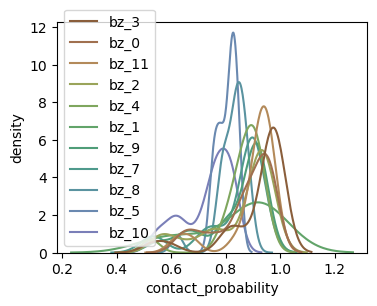

In [6]:
# Note that, because there are 10 seeds, there should be 10 models per genome, and 11 genomes with both cluster_1 and cluster_3. 
min_contact_prob = 0.5

def get_supported_contacts(contacts_df:pd.DataFrame, min_num_models:int=30, min_contact_prob=0.5):
    '''Obtain the contacts which are supported by at least min_num_models separate models.'''

    contacts_df = contacts_df[contacts_df.contact_prob > min_contact_prob].copy()
    contacts_df = contacts_df.drop_duplicates(['model', 'name', f'contact_id']) # Use the residue number mapped to the MSA so that they are comparable across genomes. 
    counts = contacts_df['contact_id'].value_counts()
    counts = counts[counts > min_num_models].copy()
    print(f'get_supported_contacts: Maximum number of models supporting any contact is:', counts.max())
    return sorted(counts.index.tolist())


supported_contact_ids = get_supported_contacts(contacts_df, min_contact_prob=min_contact_prob)
print('Number of supported contacts:', len(supported_contact_ids))
# print('\n'.join(supported_contact_ids))

fig, ax = plt.subplots(figsize=(4, 3))

figure_df = contacts_df[contacts_df.contact_prob > min_contact_prob].sort_values('contact_prob', ascending=False)
figure_df = figure_df[figure_df.contact_id.isin(supported_contact_ids)].copy()
print('Number of genomes with a supported contact:', figure_df.genome_id.nunique())

figure_df = figure_df.drop_duplicates(['contact_id', 'name', 'model']) # Keep one entry for each residue per model (the one with the highest probability).
sns.kdeplot(figure_df, x='contact_prob', hue='genome_id', common_norm=False)
ax.set_ylabel('density')
ax.set_xlabel('contact_probability')
ax.get_legend().set_title('')
plt.show()

In [7]:
def plot_entropy(msa:MSAFile, max_entropy=0.1, x_min=20, x_max=70):

    fig, ax = plt.subplots(figsize=((x_max - x_min) / 5, 3))

    entropy = msa.get_entropy(alphabet=REDUCED_ALPHABET, exclude_gaps=True)

    ax.plot(np.arange(len(entropy)), entropy, color='gray')

    conserved_idxs = np.where((entropy < max_entropy) & (~np.isnan(entropy)))[0] 
    # conserved_idxs = [idx for idx in conserved_idxs if (msa.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
    conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

    for idx, aas in zip(conserved_idxs, conserved_aas):
        if (idx > x_max) or (idx < x_min):
            continue
        ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
        ax.axvline(idx, color='black', lw=0.5)

    x_ticks = np.arange(x_min, x_max, 2)
    ax.set_xticks(x_ticks, labels=x_ticks, fontsize='xx-small')
    ax.set_xlim(xmin=x_min, xmax=x_max)
    ax.set_ylabel('entropy')
    plt.show()

# plot_entropy(msas[3], x_min=30, x_max=75)
# plot_entropy(msas[3], x_min=200, x_max=210)
# plot_entropy(msas[1], x_min=25, x_max=60)

In [31]:
get_group_id = lambda node_id : node_id.split(':')[0]
get_n = lambda node_id : int(node_id.split(':')[1])


def get_pos(graph):
    '''Obtain positions for nodes in a contact graph. Positions are determined by the node ID format. Node IDs are of the format {group_id}:{n}, 
    where the group_1 determines the horizontal position of a node, and the n determines the vertical position.
    
    :param graph:
    :returns: A dictionary mapping each node ID in the input graph to an (x, y) position. 
    '''

    assert np.all([re.match(r'.+:\d+', node_id) for node_id in list(graph.nodes)]), f'get_pos: Some of the node IDs are not in the correct format.'

    groups = dict()
    for node_id in list(graph.nodes):
        group_id = get_group_id(node_id)
        if group_id not in groups:
            groups[group_id] = list()
        groups[group_id].append(node_id)

    x_pos, y_pos = 0, 0
    pos = dict()
    for group_id, node_ids in groups.items():
        for node_id in sorted(node_ids, key=get_n): # Order according to the residue number
            pos[node_id] = (x_pos, y_pos)
            y_pos += 1
        x_pos += 1
        y_pos = 0 # Reset the y position for the next column. 

    return pos 


def plot_contacts(contacts_df:pd.DataFrame, palette={'cluster_1':'lightgray', 'cluster_3':'gray'}):
    '''Construct a networkx Graph object using the contacts in the contacts_df, and plot the graph with a custom
    layout, where nodes are positioned in columns corresponding to groups (see get_pos)
    
    :param contacts_df:
    :param palette:
    :returns None:
    '''

    graph = nx.Graph()
    graph_df = contacts_df.copy()

    node_ids = np.unique([node_id for node_ids in graph_df.contact_id for node_id in node_ids.split('-')])
    node_colors = [palette.get(get_group_id(node_id), 'black') for node_id in node_ids] 

    graph.add_nodes_from(node_ids)

    for contact_id in graph_df.contact_id:
        graph.add_edge(*contact_id.split('-'))


    fig, ax = plt.subplots(figsize=(10, 10))

    pos = get_pos(graph)
    nx.draw_networkx_nodes(graph, pos=pos, node_color=node_colors, label=node_ids)
    nx.draw_networkx_edges(graph, pos=pos, edge_color='black')
    nx.draw_networkx_labels(graph, pos, labels=dict(zip(node_ids, node_ids)))

    for _, spine in ax.spines.items():
        spine.set_visible(False)

    plt.show()



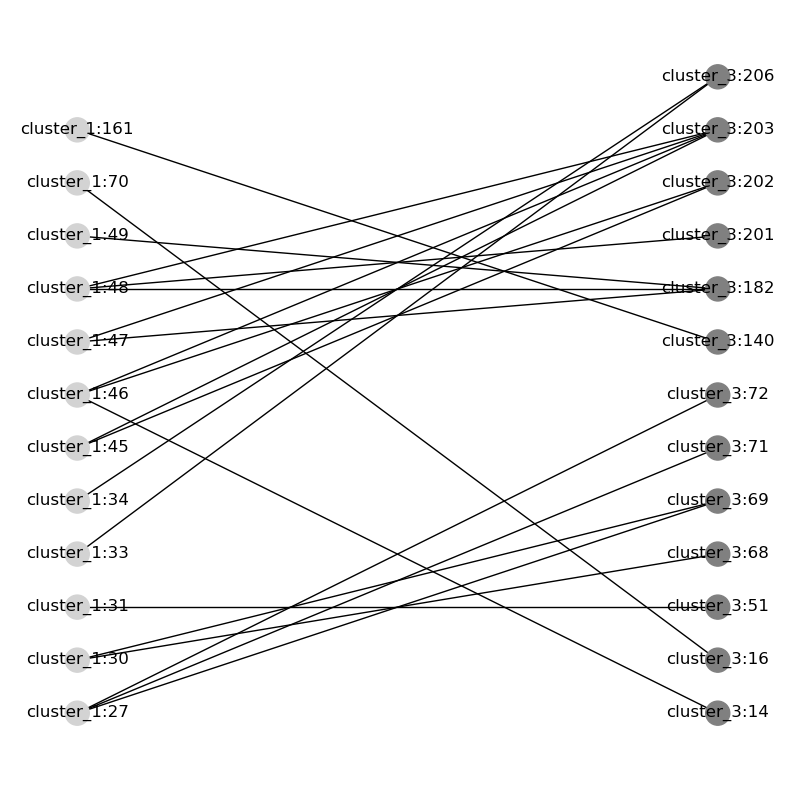

In [32]:


# plot_contacts(contacts_df[(contacts_df.genome_id == 'bz_0') & (contacts_df.contact_prob > 0.75)])
plot_contacts(contacts_df[contacts_df.contact_id.isin(supported_contact_ids)])



In [10]:
# # Copy structures over for DALI search via the web interface. 
# for output_dir in glob.glob(os.path.join(ALPHAFOLD_DIR, 'server', '*')):
#     output = AlphaFoldServerOutput(output_dir)
#     if ('cluster_1' in output.name) and ('cluster_3' not in output.name):
#         output_path = os.path.join('/home/prichter/Downloads/', f'{output.name}.pdb')
#         cif_to_pdb(output.best_model_path, output_path=output_path)

In [12]:
# First, I want to use one of the genomes to determine the stoichiometry of the cluster_1 and cluster_3 monomers, and how ATP or ADP binding 
# alters the configuration. 

# From some trial and error on the AlphaFold server, it is clear that cluster_3 does not fold into a stable hexamer without either ATP or ADP bound (otherwise,
# it does not form a nice ring, kind of just a blob of monomers)

path = os.path.join(ALPHAFOLD_INPUT_DIR, 'cluster_1-cluster_3.json')
counts = [(1, 1), (2, 6), (1, 6), (3, 6), (12, 6), (6, 6)] # Counts for the cluster_1 and cluster_3 subunits, respectively. 
msas = get_msas_unpaired(genes_df.index)

inputs = list()
for genome_id, df in genes_df[genes_df.genome_id == 'bz_0'].groupby('genome_id'):
    df = df.sort_values('cluster_id') # Make sure cluster_1 is first. 
    cluster_1_entry = df[df.cluster_id == 1].iloc[0]
    cluster_3_entry = df[df.cluster_id == 3].iloc[0]

    for (cluster_1_count, cluster_3_count), ligand in itertools.product(counts, ['adp', 'atp']):

        name = f'{cluster_1_entry.gene_id}_{cluster_1_count}mer-{cluster_3_entry.gene_id}_{cluster_3_count}mer-mg_{ligand}'

        input = AlphaFoldInputFile(name, dialect='alphafoldserver', num_seeds=1, version=2)
        input.add_seq(cluster_1_entry.seq, paired_msa='', unpaired_msa=msas[cluster_1_entry.original_gene_id], n=cluster_1_count)
        input.add_seq(cluster_3_entry.seq, paired_msa='', unpaired_msa=msas[cluster_3_entry.original_gene_id], n=cluster_3_count)
        input._add_ligand(type_=ligand, n=cluster_3_count)
        input._add_ligand(type_='mg', n=cluster_3_count)

        print(f'Generated input for {input.name}.')
        inputs.append(input)

    for ligand in ['adp', 'atp']:
        input = AlphaFoldInputFile(f'{genome_id}_cluster_3_6mer-mg_{ligand}', dialect='alphafoldserver', num_seeds=1, version=2)
        input.add_seq(cluster_3_entry.seq, paired_msa='', unpaired_msa=msas[cluster_3_entry.original_gene_id], n=6)
        input._add_ligand(type_=ligand, n=cluster_3_count)
        input._add_ligand(type_='mg', n=cluster_3_count)

        print(f'Generated input for {input.name}.')
        inputs.append(input)


with open(path, 'w') as f:
    json.dump([input.get_info() for input in inputs], f)

# find . -type f -name 'fold_*' -exec rename 's|/fold_|/|' {} +
output_dirs = [os.path.join('../data/genes/alphafold/server/', input.name.replace('-', '_')) for input in inputs]
outputs = [AlphaFoldServerOutput(path) for path in output_dirs if os.path.exists(path)]
print(f'\nLoaded {len(outputs)} AlphaFoldServer outputs.')

# Based on the ipTMs of the best models, it seems as though the ATP-bound structures for bz_0 are more confident than the ADP-bound structures. 
outputs = [output for output in outputs if ('atp' in output.name)]
print(f'Retained {len(outputs)} ATP-bound structures.')
# for output in outputs:
#     print(output.name, output.get_iptms(best_model=True))


Generated input for bz_0_cluster_1_1mer-bz_0_cluster_3_1mer-mg_adp.
Generated input for bz_0_cluster_1_1mer-bz_0_cluster_3_1mer-mg_atp.
Generated input for bz_0_cluster_1_2mer-bz_0_cluster_3_6mer-mg_adp.
Generated input for bz_0_cluster_1_2mer-bz_0_cluster_3_6mer-mg_atp.
Generated input for bz_0_cluster_1_1mer-bz_0_cluster_3_6mer-mg_adp.
Generated input for bz_0_cluster_1_1mer-bz_0_cluster_3_6mer-mg_atp.
Generated input for bz_0_cluster_1_3mer-bz_0_cluster_3_6mer-mg_adp.
Generated input for bz_0_cluster_1_3mer-bz_0_cluster_3_6mer-mg_atp.
Generated input for bz_0_cluster_1_12mer-bz_0_cluster_3_6mer-mg_adp.
Generated input for bz_0_cluster_1_12mer-bz_0_cluster_3_6mer-mg_atp.
Generated input for bz_0_cluster_1_6mer-bz_0_cluster_3_6mer-mg_adp.
Generated input for bz_0_cluster_1_6mer-bz_0_cluster_3_6mer-mg_atp.
Generated input for bz_0_cluster_3_6mer-mg_adp.
Generated input for bz_0_cluster_3_6mer-mg_atp.

Loaded 14 AlphaFoldServer outputs.
Retained 7 ATP-bound structures.


In [39]:
# Want to look at the three different possible interfaces: cluster_1-cluster_3 interface, cluster_1-cluster_1 interface, and the cluster_3-cluster_3 interface. 
if not os.path.exists('analysis-1-cluster_1-cluster_3-contacts.csv'):
    contacts_df = list()
    for output in tqdm(outputs, desc='Loading contact data.'):
        contacts_df.append(get_contacts(output, min_contact_prob=0.3))
    contacts_df = pd.concat(contacts_df)
    contacts_df.to_csv('analysis-1-cluster_1-cluster_3-contacts.csv', index=False)
else:
    contacts_df = pd.read_csv('analysis-1-cluster_1-cluster_3-contacts.csv')

msas = dict()
msas[1] = MSAFile.from_file('../data/genes/cluster_1.afa')
msas[3] = MSAFile.from_file('../data/genes/cluster_3.afa')
# Replace the MSA gene IDs to match the grouped versions, e.g. bz_0_cluster_1.
msas[1].ids = genes_df.loc[msas[1].ids].gene_id.values
msas[3].ids = genes_df.loc[msas[3].ids].gene_id.values

contacts_df = contacts_df.dropna(axis=0)
contacts_df['gene_id_0'] = contacts_df.seq_0.map(SEQ_TO_GENE_ID_MAP)
contacts_df['gene_id_1'] = contacts_df.seq_1.map(SEQ_TO_GENE_ID_MAP)
contacts_df['cluster_id_0'] = contacts_df.seq_0.map(SEQ_TO_CLUSTER_ID_MAP).astype(int)
contacts_df['cluster_id_1'] = contacts_df.seq_1.map(SEQ_TO_CLUSTER_ID_MAP).astype(int)
contacts_df['msa_residue_num_0'] = contacts_df.apply(lambda row : msas[row.cluster_id_0].map_idx_to_msa(row.residue_num_0, row.gene_id_0), axis=1)
contacts_df['msa_residue_num_1'] = contacts_df.apply(lambda row : msas[row.cluster_id_1].map_idx_to_msa(row.residue_num_1, row.gene_id_1), axis=1)

# get_contact_id = lambda row : '-'.join(sorted([f'cluster_{row.cluster_id_0}:{int(row.residue_num_0)}', f'cluster_{row.cluster_id_1}:{int(row.residue_num_1)}']))
get_contact_id = lambda row : '-'.join(sorted([f'cluster_{row.cluster_id_0}:{int(row.msa_residue_num_0)}', f'cluster_{row.cluster_id_1}:{int(row.msa_residue_num_1)}']))
contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)


apply_filters: 10970 entries removed by same_cluster_contacts.
apply_filters: 11650 entries removed by low_contact_prob.
apply_filters: 13300 entries removed by wrong_stoichiometry.


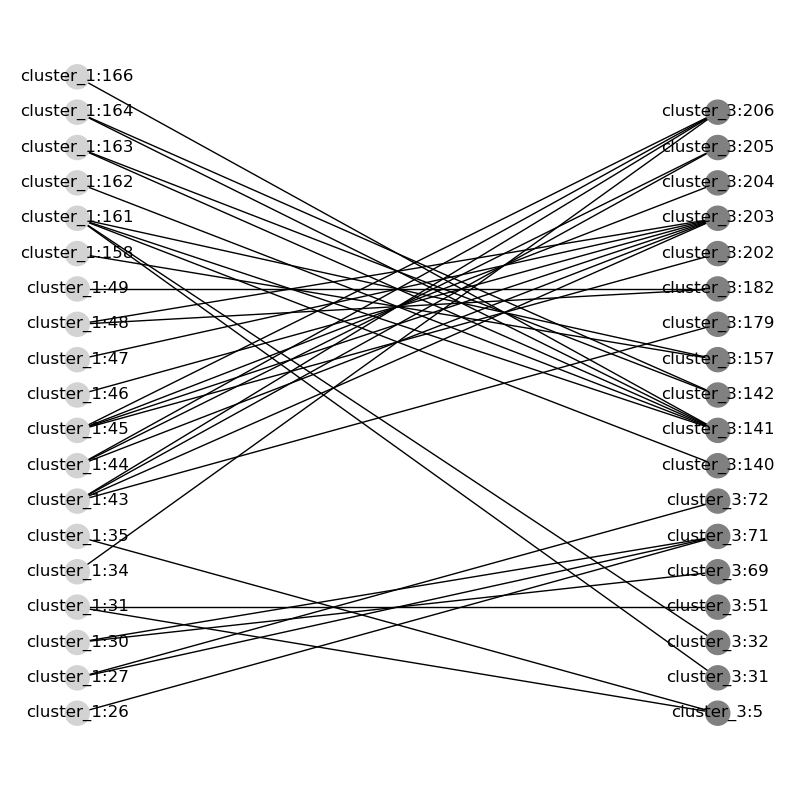

In [43]:
filters = dict()
filters['same_cluster_contacts'] = contacts_df.cluster_id_0 == contacts_df.cluster_id_1
filters['low_contact_prob'] = contacts_df.contact_prob < 0.6
filters['wrong_stoichiometry'] = contacts_df.name.str.count('6mer') < 2


figure_df = apply_filters(filters, contacts_df)
plot_contacts(figure_df)

In [ ]:
# # Looking at the ipTM score in these cases might not be particularly informative, as the comparatively low pTM scores for the 
# # cluster_1 proteins will drag down the mean of the complex. Instead, it is best to look directly at the interfaces. 
# # I want to consider how often a particular residue participates in a contact across different chain pairs and models, what it is contacting, 
# # and the contact probability, which is probably easiest with a graph. 

# # For each possible stoichiometry and ligand specification, I did the following analysis:
# #   (1) Obtain the residues with contact probability > 0.5 between each pair of chains. 
# #   (2) Construct an undirected graph based on the predicted contacts. 

# # (gene_id, residue_num, residue, contact_prob, model_name, pae) - (gene_id, residue_num, residue, contact_prob, model_name, pae)

# data = dict()

# def get_gene_id_map(token_chain_ids:np.ndarray, genes_df:pd.DataFrame=genes_df):
#     '''Use the lengths of each chain to map the chain IDs to the gene ID. Note that this is not ideal, but seems to be the simplest way to do this while
#     AlphaFold on biotite does not support chain descriptions.
    
#     :param token_chain_ids:
#     :param genes_df:
#     :returns:
#     '''
#     # Rename the gene IDs based on their cluster membership and genome. This is so that the edge IDs (below) are consistent across
#     # different genomes (i.e. cluster_1 always precedes cluster_3 in the ID)
#     genes_df.index = [f'{row.genome_id}_cluster_{int(row.cluster_id)}' for row in genes_df.itertuples()]

#     lengths = genes_df.seq.apply(len)
#     assert np.all(lengths.value_counts() == 1), f'get_gene_id_map: Protein lengths are not unique.'
#     lengths = lengths.reset_index(name='length').rename(columns={'index':'gene_id'}).set_index('length').gene_id.to_dict() #.gene_id.to_dict()
    
#     gene_id_map = dict()
#     for chain_id, length in zip(*np.unique(token_chain_ids, return_counts=True)):
#         gene_id_map[chain_id] = lengths.get(length, 'none')
#     return gene_id_map


# def get_residue(idx, token_chain_ids:np.ndarray):
#     '''

#     :param idx: The zero-indexed contact location relative to the token_chain_ids array. 
#     :param token_chain_ids: The token_chain_ids array from the AlphaFold output. 
#     :returns: A two-tuple containing (1) the chain ID and (2) zero-indexed residue number relative to the start of the chain. 
#     '''
#     chain_start_idxs = dict(zip(*np.unique(token_chain_ids, return_index=True))) # This is a dictionary mapping the chain IDs to their start indices.
#     chain_id = token_chain_ids[idx] # Get the chain that the specified index belongs to. 
#     return (chain_id, idx - chain_start_idxs[chain_id])


# def get_contacts(contact_probs_df:np.ndarray, min_contact_prob=0.3):
#     '''Use the contact_probs in the AlphaFold output to locate potential inter-chain residue contacts.
    
#     :param contact_probs_df: A square DataFrame containing the contact_probs for a given structure. 
#     :param min_contact_prob: The minimum contact_prob to say whether or not two residues are likely to be in contact. 
#     :returns:
#     '''
#     token_chain_ids = contact_probs_df.index.values
#     mask = (contact_probs_df.values > min_contact_prob) # Require a minimum contact probability. 
#     mask = mask & (np.expand_dims(token_chain_ids, axis=1) != np.expand_dims(token_chain_ids, axis=0))  # Don't include intra-chain contacts. 
#     # print(f'get_contacts: {mask.sum().sum()} inter-chain residues predicted to be in contact.')
#     return list(zip(*np.where(mask))) # Gets the contact indices as a list of two-tuples (i1, j1), (12, j2), ...


# def get_edge_id(row:dict):
#     '''Obtain an ID for an edge in the contact graph.

#     :param row: A dictionary containing row information for the contacts_df DataFrame (see below).
#     :returns: An "edge" ID, which encodes a contact between two proteins (not chains, i.e. when there are multiple chains per protein, 
#         these will map to the same edge ID). 
    
#     '''
#     node_ids = [row[f'gene_id_{i}'] + ':' + str(row[f'residue_num_{i}']) for i in range(2)]
#     node_ids = sorted(node_ids)
#     return '-'.join(node_ids)


# if not os.path.exists('analysis-1-cluster_1-cluster_3-bz_0_contacts.csv'):
#     contacts_df = list()

#     # for output in outputs:
#     for output in tqdm(outputs, desc='Processing contact data.'):

#         contact_probs_df = output.get_contact_probs(best_model=True)
#         paes_df =  output.get_paes(best_model=True)
#         token_chain_ids = output.get_token_chain_ids()
#         # When constructing the gene ID map, need to filter by genome ID, as genes in different organisms have the same length. 
#         gene_id_map = get_gene_id_map(token_chain_ids, genes_df=genes_df[genes_df.genome_id == get_genome_id(output.name)])

#         for idxs in get_contacts(contact_probs_df):
#             row = dict()
#             for i, idx in enumerate(idxs):
#                 row[f'idx_{i}'] = idx 
#                 row[f'chain_id_{i}'], row[f'residue_num_{i}'] = get_residue(idx, token_chain_ids)
#                 row[f'gene_id_{i}'] = gene_id_map[row[f'chain_id_{i}']]
#             row['edge_id'] = get_edge_id(row)
#             row['pae'] = min(paes_df.iloc[idxs[0], idxs[1]], paes_df.iloc[idxs[1], idxs[0]]) # PAE is not symmetric. 
#             row['contact_prob'] = contact_probs_df.iloc[idxs[0], idxs[1]] # This should be symmetric. 
#             row['name'] = output.name 

#             contacts_df.append(row)

#     # Also want to take a look at the PAE distribution. 
#     contacts_df = pd.DataFrame(contacts_df)
#     contacts_df.to_csv('analysis-1-cluster_1-cluster_3-bz_0_contacts.csv', index=False)
# else:
#     contacts_df = pd.read_csv('analysis-1-cluster_1-cluster_3-bz_0_contacts.csv')


# name = 'bz_0_cluster_1_12mer_bz_0_cluster_3_6mer_mg_adp' # No PAE less than 22 between contacting residues in this structure. 

# filters = dict()
# # filters[f'not_{name}'] = contacts_df.name != name
# filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none')
# filters['not_cluster_3'] = ~((contacts_df.gene_id_0 == 'bz_0_cluster_3') & (contacts_df.gene_id_1 == 'bz_0_cluster_3')) 
# # filters['same_protein_contact'] = (contacts_df.gene_id_0  == contacts_df.gene_id_1)
# filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

# # Interestingly, there does not seem to be any predicted contact between the bz_1 proteins, which is potentially problematic.
# # Reduced the minimum contact probability from 0.5 to 0.3 so that I could at least check the PAE.
# graph_df = apply_filters(filters, contacts_df)
# print('Number of contacts passing filters:', len(graph_df))

In [ ]:
name = 'bz_0_cluster_1_12mer_bz_0_cluster_3_6mer_mg_adp' # No PAE less than 22 between contacting residues in this structure. 

filters = dict()
filters[f'not_{name}'] = contacts_df.name != name
filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none')
# filters['not_cluster_3'] = ~((contacts_df.gene_id_0 == 'bz_0_cluster_3') & (contacts_df.gene_id_1 == 'bz_0_cluster_3')) 
filters['same_protein_contact'] = (contacts_df.gene_id_0  == contacts_df.gene_id_1)
filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

plot_contacts(apply_filters(filters, contacts_df))

apply_filters: 23852 entries removed by not_bz_0_cluster_1_12mer_bz_0_cluster_3_6mer_mg_adp.
apply_filters: 19020 entries removed by non_protein_contact.
apply_filters: 4570 entries removed by same_protein_contact.
apply_filters: 13104 entries removed by low_contact_prob.


AttributeError: 'Pandas' object has no attribute 'residue_0'

apply_filters: 24712 entries removed by not_bz_0_cluster_1_6mer_bz_0_cluster_3_6mer_mg_adp.
apply_filters: 19020 entries removed by non_protein_contact.
apply_filters: 4570 entries removed by same_protein_contact.
apply_filters: 13104 entries removed by low_contact_prob.


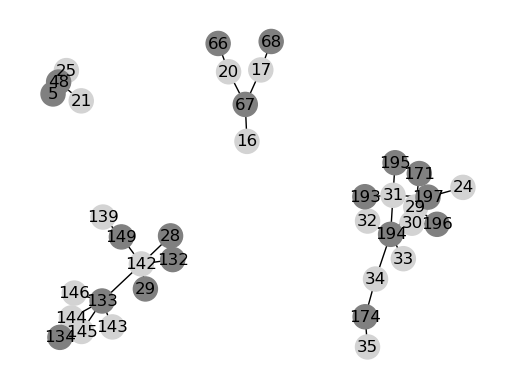

In [ ]:
name = 'bz_0_cluster_1_6mer_bz_0_cluster_3_6mer_mg_adp' # No PAE less than 22 between contacting residues in this structure. 

filters = dict()
filters[f'not_{name}'] = contacts_df.name != name
filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none')
# filters['not_cluster_3'] = ~((contacts_df.gene_id_0 == 'bz_0_cluster_3') & (contacts_df.gene_id_1 == 'bz_0_cluster_3')) 
filters['same_protein_contact'] = (contacts_df.gene_id_0  == contacts_df.gene_id_1)
filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

plot_contacts(apply_filters(filters, contacts_df))

apply_filters: 28128 entries removed by not_bz_0_cluster_1_1mer_bz_0_cluster_3_1mer_mg_adp.
apply_filters: 19020 entries removed by non_protein_contact.
apply_filters: 4570 entries removed by same_protein_contact.
apply_filters: 13104 entries removed by low_contact_prob.


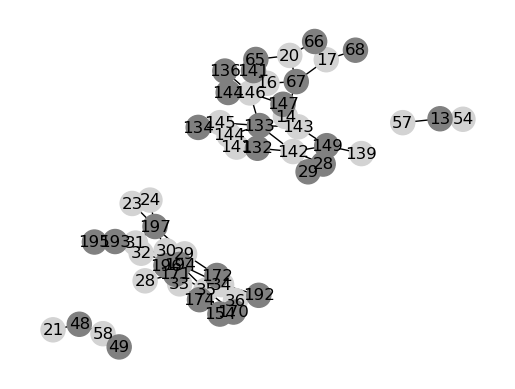

In [ ]:
name = 'bz_0_cluster_1_1mer_bz_0_cluster_3_1mer_mg_adp' # No PAE less than 22 between contacting residues in this structure. 

filters = dict()
filters[f'not_{name}'] = contacts_df.name != name
filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none')
# filters['not_cluster_3'] = ~((contacts_df.gene_id_0 == 'bz_0_cluster_3') & (contacts_df.gene_id_1 == 'bz_0_cluster_3')) 
filters['same_protein_contact'] = (contacts_df.gene_id_0  == contacts_df.gene_id_1)
filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

plot_contacts(apply_filters(filters, contacts_df))

In [ ]:
msas = dict()
msas['cluster_1'] = MSAFile.from_file('../data/genes/cluster_1.afa')
msas['cluster_3'] = MSAFile.from_file('../data/genes/cluster_3.afa')




apply_filters: 14818 entries removed by non_atp_ligand.
apply_filters: 19020 entries removed by non_protein_contact.
apply_filters: 25820 entries removed by not_cluster_3.
apply_filters: 13104 entries removed by low_contact_prob.


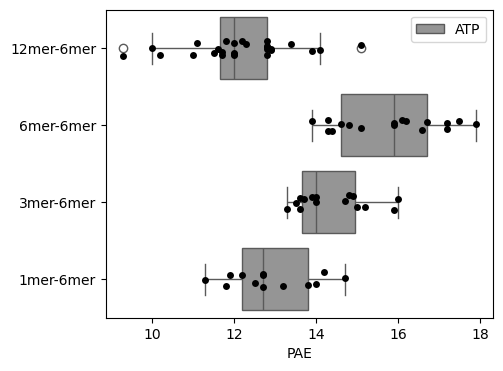

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

filters = dict()
filters['non_atp_ligand'] = ~(contacts_df.name.str.contains('atp'))
filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none') 
filters['not_cluster_3'] = ~((contacts_df.gene_id_0 == 'bz_0_cluster_3') & (contacts_df.gene_id_1 == 'bz_0_cluster_3')) 
filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

metric = 'pae'

figure_df = apply_filters(filters, contacts_df).copy()

conditions = [figure_df.name.str.contains('mg_atp'), figure_df.name.str.contains('mg_adp')]
figure_df['ligand'] = np.select(conditions, ['ATP', 'ADP'], default='none')
figure_df = figure_df.sort_values('contact_prob', ascending=False).drop_duplicates(['edge_id', 'name'], keep='first')

sns.boxplot(figure_df, y='name', x=metric, hue='ligand', palette='Grays')
sns.stripplot(figure_df, y='name', x=metric, color='black')

labels = ['-'.join(re.findall(r'\d+mer', label.get_text())) for label in ax.get_yticklabels()]
ax.set_yticks(ax.get_yticks(), labels=labels)
ax.set_ylabel('')
ax.set_xlabel('PAE' if (metric == 'pae') else 'contact probability')

plt.show()

apply_filters: 14818 entries removed by non_atp_ligand.
apply_filters: 19020 entries removed by non_protein_contact.
apply_filters: 4570 entries removed by same_protein_contact.
apply_filters: 13104 entries removed by low_contact_prob.
apply_filters: 14818 entries removed by non_atp_ligand.
apply_filters: 19020 entries removed by non_protein_contact.
apply_filters: 4570 entries removed by same_protein_contact.
apply_filters: 13104 entries removed by low_contact_prob.


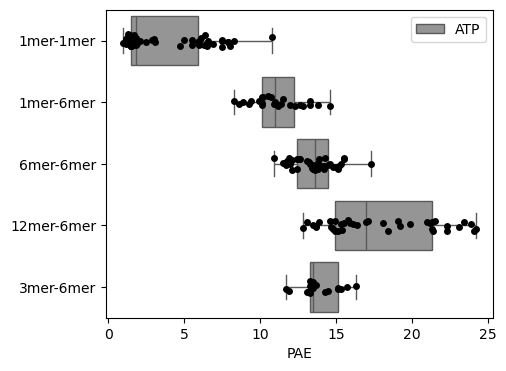

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

filters = dict()
filters['non_atp_ligand'] = ~(contacts_df.name.str.contains('atp'))
filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none') 
filters['same_protein_contact'] = (contacts_df.gene_id_0  == contacts_df.gene_id_1)
filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

figure_df = apply_filters(filters, contacts_df).copy()

metric = 'pae'

figure_df = apply_filters(filters, contacts_df).copy()

conditions = [figure_df.name.str.contains('mg_atp'), figure_df.name.str.contains('mg_adp')]
figure_df['ligand'] = np.select(conditions, ['ATP', 'ADP'], default='none')
figure_df = figure_df.sort_values('contact_prob', ascending=False).drop_duplicates(['edge_id', 'name'], keep='first')

sns.boxplot(figure_df, y='name', x=metric, hue='ligand', palette='Grays')
sns.stripplot(figure_df, y='name', x=metric, color='black')

labels = ['-'.join(re.findall(r'\d+mer', label.get_text())) for label in ax.get_yticklabels()]
ax.set_yticks(ax.get_yticks(), labels=labels)
ax.set_ylabel('')
ax.set_xlabel('PAE' if (metric == 'pae') else 'contact probability')

plt.show()

In [ ]:
# fig, axes = plt.subplots(ncols=2, figsize=(15, 4), sharey=False)

# keep = lambda name : (genome_id in name)

# for data_ in data.values():

#     if not keep(data_['name']):
#         continue 
#     name = data_['name'].replace(f'fold_{genome_id}_', '').replace(f'{genome_id}_', '')


#     n = data_['num_contacts']

#     # print(f'Maximum contact probability for {name}:', max(data_['contact_probs']))
#     print(f'Number of contacts for {name} with > 70% probability:', (np.array(data_['contact_probs']) > 0.7).sum())
#     if len(data_['pae']) < 2:
#         print(f'Skipping {name}, only one contact found.')
#         continue

#     sns.kdeplot(data_['pae'], label=f'{name} (n={n})', ax=axes[0])
#     sns.kdeplot(data_['contact_probs'], label=f'{name} (n={n})', ax=axes[1])

# axes[1].legend(bbox_to_anchor=(1.1, 0.6))

# axes[0].set_ylabel('density')
# axes[1].set_ylabel('density')

# axes[0].set_title('PAE')
# axes[1].set_title('contact probability')

# fig.tight_layout()
# plt.show()


In [ ]:

# cluster_1_gene_id = CLUSTER_1_GENE_IDS[genome_id]
# cluster_3_gene_id = CLUSTER_3_GENE_IDS[genome_id]

# dssp_df = [DSSPFile.from_file(os.path.join(DSSP_OUTPUT_DIR, f'{cluster_1_gene_id}.dssp')).to_df().assign(cluster_id=1)]
# dssp_df += [DSSPFile.from_file(os.path.join(DSSP_OUTPUT_DIR, f'{cluster_3_gene_id}.dssp')).to_df().assign(cluster_id=3)]
# dssp_df = pd.concat(dssp_df).rename(columns={'residue':'idx', 'aa':'residue'}).drop(columns=['chain', 'code'])
# dssp_df['idx'] = dssp_df['idx'] - 1 # Need to shift the index to be zero-indexed. 

# figure_df = pd.DataFrame()

# for name in [f'fold_{genome_id}_cluster_1_6mer_{genome_id}_cluster_3_6mer_mg_atp', f'fold_{genome_id}_cluster_1_1mer_{genome_id}_cluster_3_1mer_mg_atp']:

#     contacts = dict()
#     contacts[1] = np.unique(data[name]['idxs_shifted'][0])
#     contacts[3] = np.unique(data[name]['idxs_shifted'][1])

#     for cluster_id, idxs in contacts.items():
#         for idx in idxs:
#             residue = CLUSTER_1_SEQS[genome_id][idx] if (cluster_id == 1) else CLUSTER_3_SEQS[genome_id][idx]
#             figure_df.loc[f'{residue}{idx}', name] = True
#             figure_df.loc[f'{residue}{idx}', 'idx'] = idx
#             figure_df.loc[f'{residue}{idx}', 'residue'] = residue
#             figure_df.loc[f'{residue}{idx}', 'cluster_id'] = cluster_id

# figure_df = figure_df.fillna(False)
# index = figure_df.index.copy()
# figure_df = figure_df.merge(dssp_df, on=['cluster_id', 'idx', 'residue'], how='left')
# figure_df.index = index

# fig, axes = plt.subplots(ncols=2, figsize=(6, 8))

# label_map = dict()
# label_map[f'fold_{genome_id}_cluster_1_6mer_{genome_id}_cluster_3_6mer_mg_atp'] = '6-mer complex'
# label_map[f'fold_{genome_id}_cluster_1_1mer_{genome_id}_cluster_3_1mer_mg_atp'] = '1-mer complex'

# for ax, (cluster_id, df) in zip(axes, figure_df.groupby('cluster_id')):
#     sns.heatmap(df[list(label_map.keys())].astype(int), ax=ax, cbar=False, cmap='binary')
#     ax.set_title(f'cluster {int(cluster_id)}')
#     ax.twinx().set_yticks(ax.get_yticks(), labels=df.structure.values[::-1])
#     ax.set_xticks(ax.get_xticks(), labels=[label_map.get(label.get_text()) for label in ax.get_xticklabels()])

# fig.tight_layout()
# plt.show()

In [ ]:
# def get_num_models_with_contact(contacts_df:pd.DataFrame, i:int=0, min_num_models:int=30):
#     '''Obtain the number of times a particular residue participates in an inter-chain contact across different models. 
#     In other words, if a residue participates in multiple contacts within the same model, only count the residue once.
#     Note that the model names themselves are not unique, so need to account for the names when de-duplicating. '''
#     contacts_df = contacts_df.drop_duplicates(['model', 'name', f'msa_residue_num_{i}']) # Use the residue number mapped to the MSA so that they are comparable across genomes. 
#     counts = contacts_df[f'msa_residue_num_{i}'].value_counts()
#     counts = counts[counts > min_num_models].copy()
#     return counts 

# def get_num_genomes_with_contact(contacts_df:pd.DataFrame, i:int=0):
#     '''Obtain the number of times a particular residue participates in an inter-chain contact across different genomes.'''
#     # Only keep one instance of the interaction per genome. 
#     contacts_df = contacts_df.drop_duplicates(['genome_id', f'msa_residue_num_{i}']) # Use the residue number mapped to the MSA so that they are comparable across genomes. 
#     counts = contacts_df[f'msa_residue_num_{i}'].value_counts()
#     return counts 

In [ ]:
# # There are 10 models per genome, so if a contact appears more than 10 times, it must appear in multiple genomes. 

# idxs = num_models_with_contact.index.values.astype(int)
# n = len(num_models_with_contact)
# print('Number of conserved contact residues:', n)

# fig, axes = plt.subplots(figsize=(n * 3, 3), ncols=n)

# for ax, idx in zip(axes, sorted(idxs)):
#     figure_df = contacts_df[contacts_df.msa_residue_num_0 == idx].copy()
#     sns.histplot(ax=ax, data=figure_df, x='residue_0', color='lightgray')
#     ax.set_title(f'position {idx}')

# # for ax, idx in zip(axes, sorted(idxs)):
# #     sns.histplot(ax=ax, x=msas[1].to_array().T[idx])
# #     ax.set_title(f'position {idx}')

# fig.tight_layout()